No data specified. Sanity checks related to the length of the signal relative to the filter order will be skipped.
Setting up band-pass filter from 8 - 12 Hz

FIR filter parameters
---------------------
Designing a one-pass, non-linear phase, causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 2.00 Hz
- Upper transition bandwidth: 3.00 Hz
- Filter length: 423 samples (1.652 s)

Setting up band-pass filter from 8 - 12 Hz

FIR filter parameters
---------------------
Designing a one-pass, non-linear phase, causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 2.00 Hz
- Upper transition bandwidth: 3.00 Hz
- Filter length: 423 samples (1.652 s)

Effective filter duration (95% energy): 460.9 ms


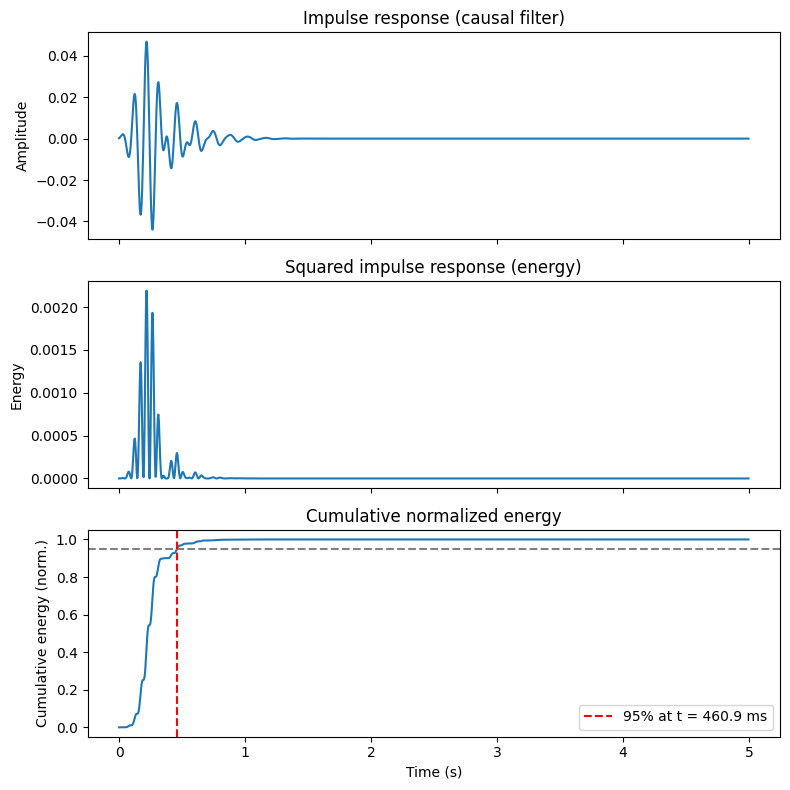

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import mne

# Parameters matching your EEG recording / pipeline.
sfreq = 256.0
l_freq = 8 # 0.1
h_freq = 12 # 40.0

# Length of impulse test signal.
duration_sec = 10.0
n_samples = int(duration_sec * sfreq)

# Create the impulse (delta function) input.
impulse = np.zeros(n_samples)
impulse[n_samples // 2] = 1.0 # impulse in the middle to allow for both causal and acausal filters.

# Design filter
filt_params = dict(
    sfreq = sfreq,
    l_freq = l_freq,
    h_freq = h_freq,
    method = 'fir',
    phase = 'minimum',
    fir_design = 'firwin',
    verbose = True
)

# Get the actual filter coefficients:
filt = mne.filter.create_filter(
    data = None,
    **filt_params
)

# Apply the same filter MNE would apply to your real data
filtered_impulse = mne.filter.filter_data(
    impulse[np.newaxis, :],
    **filt_params
)[0]

# Extract the impulse response
impulse_idx = n_samples // 2
h = filtered_impulse[impulse_idx:] # keep only samples from t = 0 onward
time = np.arange(len(h)) / sfreq

# Square (energy), cumulative sum, normalize:
energy = h ** 2
cum_energy = np.cumsum(energy)
cum_energy_norm = cum_energy / cum_energy[-1]

# Find 95% energy duration: "time-to-convergence"
threshold = 0.95
idx_95 = np.searchsorted(cum_energy_norm, threshold)
t_95 = time[idx_95]

print(f"Effective filter duration (95% energy): {t_95*1000:.1f} ms")

#####

fig, axes = plt.subplots(3, 1, figsize = (8, 8), sharex = True)

axes[0].plot(time, h)
axes[0].set_title("Impulse response (causal filter)")
axes[0].set_ylabel("Amplitude")

axes[1].plot(time, energy)
axes[1].set_title("Squared impulse response (energy)")
axes[1].set_ylabel("Energy")

axes[2].plot(time, cum_energy_norm)
axes[2].axhline(threshold, color = 'gray', linestyle = '--')
axes[2].axvline(t_95, color = 'red', linestyle = '--',
                label = f"95% at t = {t_95*1000:.1f} ms")
axes[2].set_title("Cumulative normalized energy")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Cumulative energy (norm.)")
axes[2].legend()

plt.tight_layout()
plt.show()

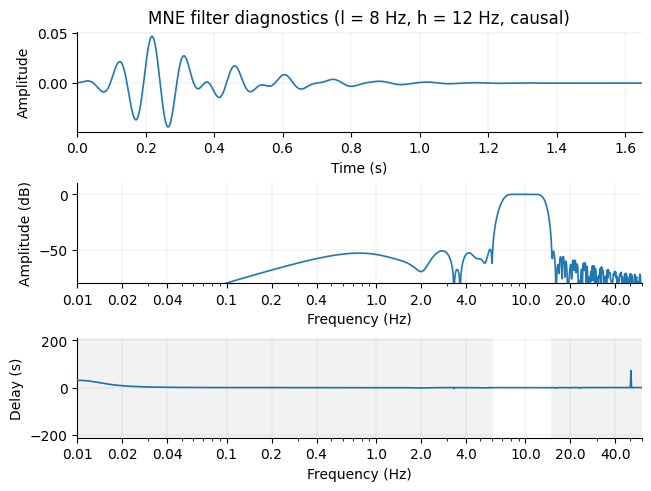

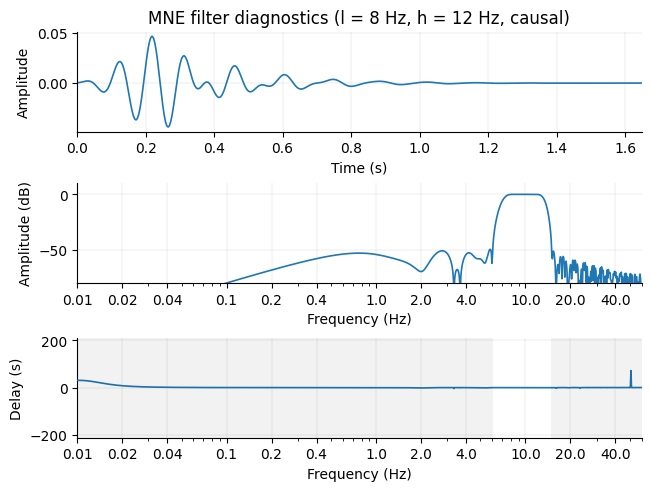

In [2]:
fmax_display = min(sfreq / 2, 60)

mne.viz.plot_filter(
    filt, sfreq,
    freq = None, gain = None,
    title = f"MNE filter diagnostics (l = {l_freq} Hz, h = {h_freq} Hz, causal)",
    flim = (0.01, fmax_display),
    show = True
)

In [ ]:
# Acausal filter:
filt_params_acausal = dict(
    sfreq = sfreq,
    l_freq = l_freq,
    h_freq = h_freq,
    method = 'fir',
    phase = 'zero',
    fir_design = 'firwin',
    verbose = True
)

filt_acausal = mne.filter.create_filter(data = None, **filt_params_acausal)

filtered_impulse_acausal = mne.filter.filter_data(
    impulse[np.newaxis, :],
    **filt_params_acausal
)[0]

h_full = filtered_impulse_acausal
time_full = (np.arange(n_samples) - impulse_idx) / sfreq

No data specified. Sanity checks related to the length of the signal relative to the filter order will be skipped.
Setting up band-pass filter from 8 - 12 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 12.00 Hz
- Upper transition bandwidth: 3.00 Hz (-6 dB cutoff frequency: 13.50 Hz)
- Filter length: 423 samples (1.652 s)

Setting up band-pass filter from 8 - 12 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 

Effective filter duration (95% energy, Acausal, symmetric): ±105.5 ms around the event


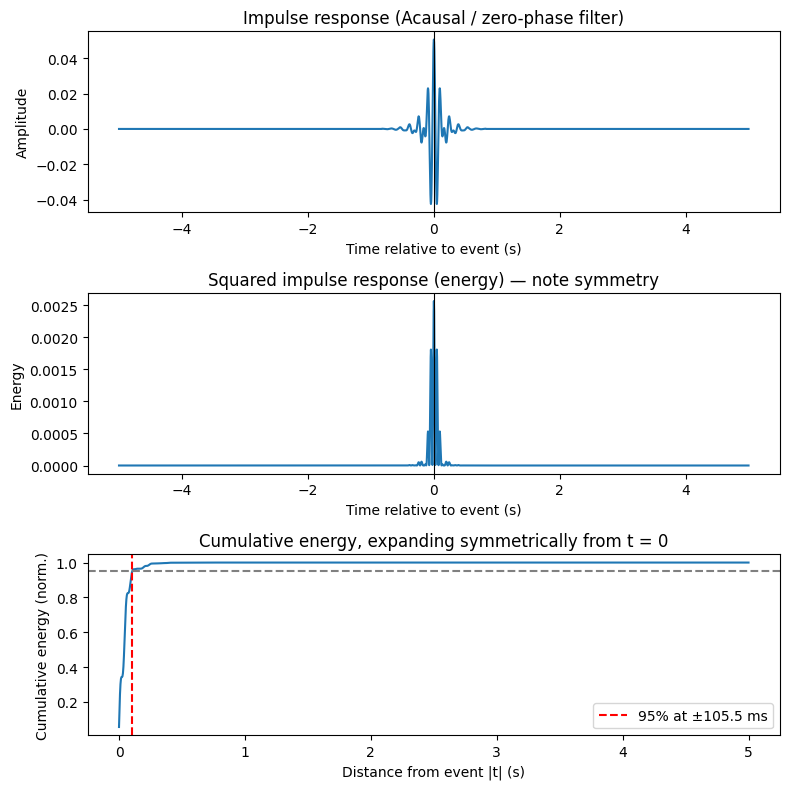

In [8]:
energy_full = h_full ** 2

past = energy_full[:impulse_idx + 1][::-1]
future = energy_full[impulse_idx:]

total_energy = past.sum() + future.sum() - energy_full[impulse_idx]

max_len = max(len(past), len(future))
cum_energy_sym = np.zeros(max_len)
running = 0.0
for i in range(max_len):
    running += (past[i] if i < len(past) else 0)
    running += (future[i] if i < len(future) else 0)
    if i == 0:
        running -= energy_full[impulse_idx]
    cum_energy_sym[i] = running

cum_energy_sym_norm = cum_energy_sym / total_energy
time_outward = np.arange(max_len) / sfreq

threshold = 0.95
idx_95_acausal = np.searchsorted(cum_energy_sym_norm, threshold)
t_95_acausal = time_outward[idx_95_acausal]

print(f"Effective filter duration (95% energy, Acausal, symmetric): "
      f"±{t_95_acausal*1000:.1f} ms around the event")

#####

fig, axes = plt.subplots(3, 1, figsize = (8, 8), sharex = False)

axes[0].plot(time_full, h_full)
axes[0].axvline(0, color = 'k', linewidth = 0.8)
axes[0].set_title("Impulse response (Acausal / zero-phase filter)")
axes[0].set_ylabel("Amplitude")
axes[0].set_xlabel("Time relative to event (s)")

axes[1].plot(time_full, energy_full)
axes[1].axvline(0, color = 'k', linewidth = 0.8)
axes[1].set_title("Squared impulse response (energy) — note symmetry")
axes[1].set_ylabel("Energy")
axes[1].set_xlabel("Time relative to event (s)")

axes[2].plot(time_outward, cum_energy_sym_norm)
axes[2].axhline(threshold, color = 'gray', linestyle = '--')
axes[2].axvline(t_95_acausal, color = 'red', linestyle = '--',
                label = f"95% at ±{t_95_acausal*1000:.1f} ms")
axes[2].set_title("Cumulative energy, expanding symmetrically from t = 0")
axes[2].set_xlabel("Distance from event |t| (s)")
axes[2].set_ylabel("Cumulative energy (norm.)")
axes[2].legend()

plt.tight_layout()
plt.show()

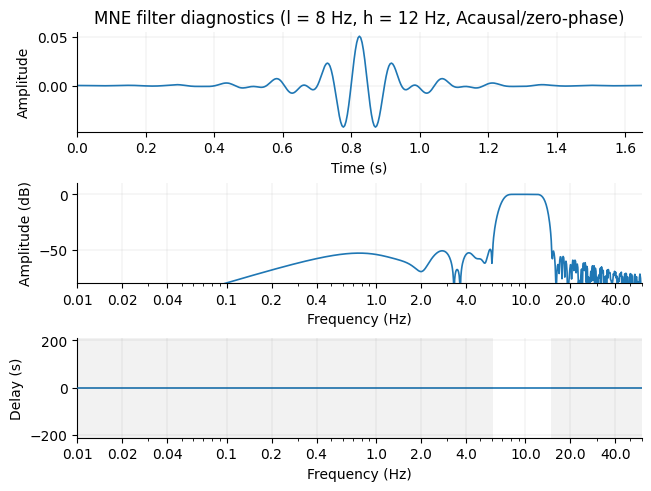

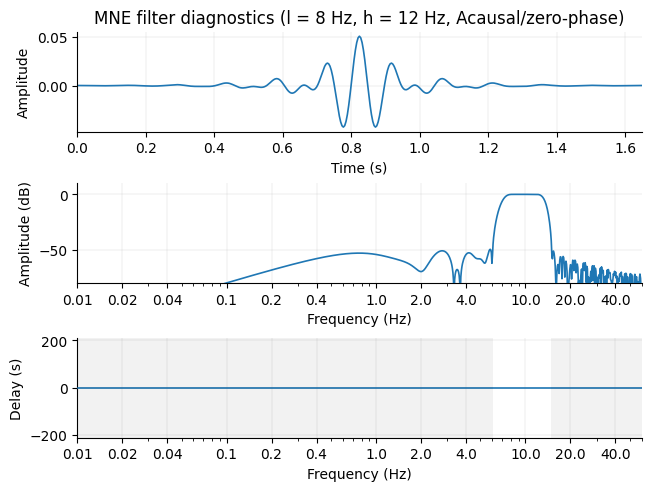

In [5]:
mne.viz.plot_filter(
    filt_acausal, sfreq,
    freq = None, gain = None,
    title=f"MNE filter diagnostics (l = {l_freq} Hz, h = {h_freq} Hz, Acausal/zero-phase)",
    flim = (0.01, fmax_display),
    show = True
)